# Dự án Titanic – Dự đoán hành khách sống sót



## 1. Định nghĩa vấn đề
- **Bài toán**: phân loại nhị phân – `Survived` (0 = chết, 1 = sống).
- **Dữ liệu**: `train.csv` (891 dòng, có nhãn), `test.csv` (418 dòng, **không có nhãn**), `gender_submission.csv` (mẫu nộp bài của Kaggle: nữ sống, nam chết).
- **Thước đo**: Accuracy (chuẩn của Kaggle), kèm F1 và ROC-AUC để nhìn rõ hơn vì lớp hơi lệch (~38% sống).


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
SEED = 7
sns.set_theme(style="whitegrid")
import os
DATA_DIR = next(d for d in [".", "titanic__2_", "../titanic__2_"] if os.path.exists(f"{d}/train.csv"))  # thư mục chứa train.csv
train = pd.read_csv(f"{DATA_DIR}/train.csv"); test = pd.read_csv(f"{DATA_DIR}/test.csv")
print(train.shape, test.shape)

(891, 12) (418, 11)


## 2. Phân tích dữ liệu

### 2.1 Thống kê mô tả

In [2]:
display(train.head())
print(train.dtypes)
print("\nGiá trị thiếu (train / test):")
print(pd.DataFrame({"train":train.isna().sum(),"test":test.isna().sum()}).query("train>0 or test>0"))
print("\nPhân phối lớp:"); print(train.Survived.value_counts(), "\n", train.Survived.value_counts(normalize=True).round(3))
display(train.describe().T.round(2))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Giá trị thiếu (train / test):
          train   test
Age         177   86.0
Cabin       687  327.0
Embarked      2    0.0
Fare          0    1.0

Phân phối lớp:
Survived
0    549
1    342
Name: count, dtype: int64 
 Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.00,257.35,1.00,223.50,446.00,668.5,891.00
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


**Nhận xét**
- `Cabin` thiếu ~77% → không dùng trực tiếp, nhưng *có/không có Cabin* có thể mang thông tin (hạng vé cao thường có số cabin).
- `Age` thiếu ~20% → cần điền (impute). `Embarked` thiếu 2 dòng; `Fare` thiếu 1 dòng ở test.
- Lớp lệch nhẹ (61.6% chết / 38.4% sống): baseline "luôn đoán chết" đã đạt ~61.6% → mọi mô hình phải vượt mốc này.

### 2.2 Trực quan hóa

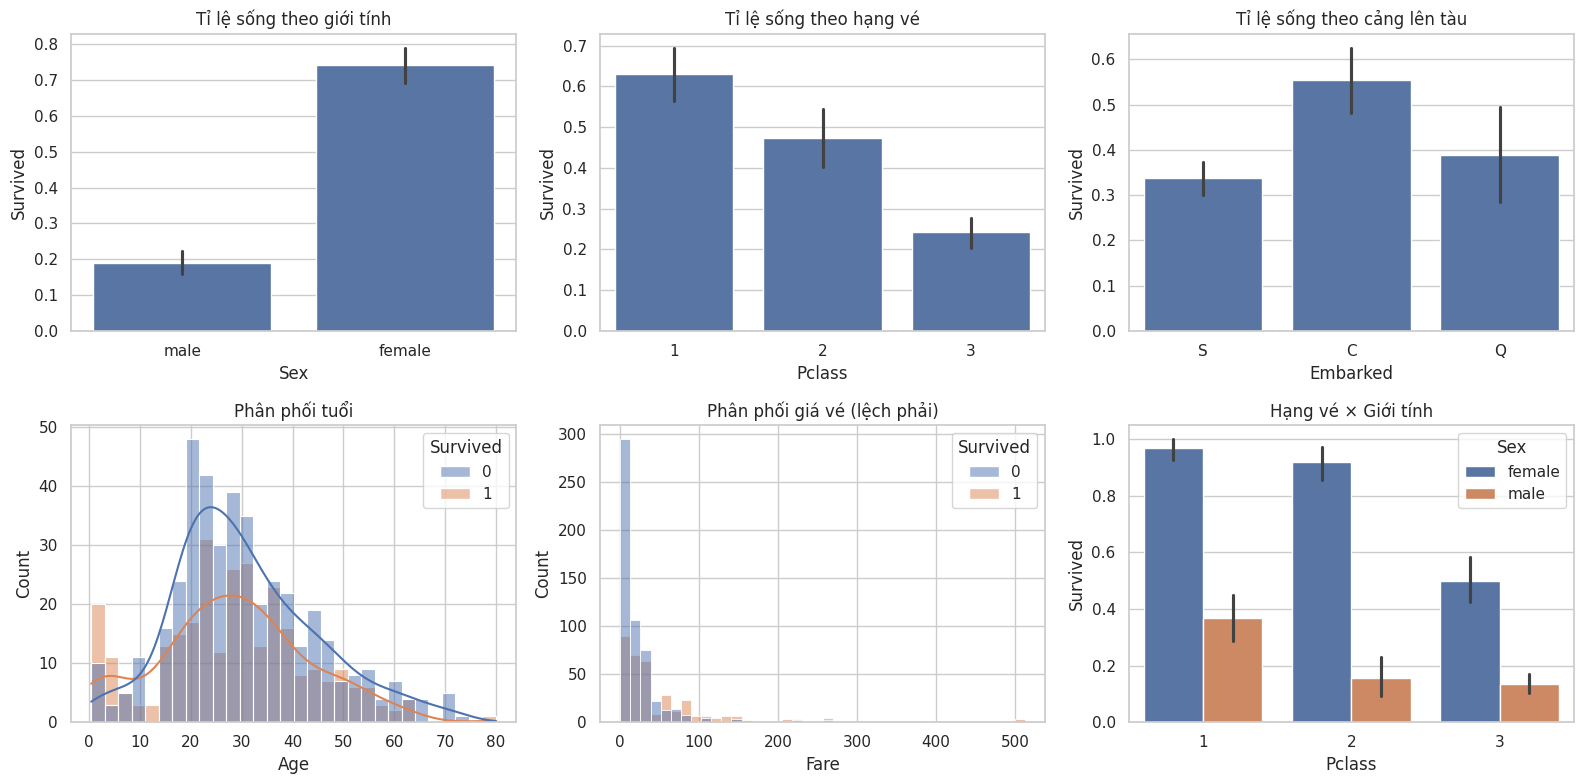

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
sns.barplot(data=train, x="Sex", y="Survived", ax=ax[0,0]); ax[0,0].set_title("Tỉ lệ sống theo giới tính")
sns.barplot(data=train, x="Pclass", y="Survived", ax=ax[0,1]); ax[0,1].set_title("Tỉ lệ sống theo hạng vé")
sns.barplot(data=train, x="Embarked", y="Survived", ax=ax[0,2]); ax[0,2].set_title("Tỉ lệ sống theo cảng lên tàu")
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True, ax=ax[1,0]); ax[1,0].set_title("Phân phối tuổi")
sns.histplot(data=train, x="Fare", hue="Survived", bins=40, ax=ax[1,1]); ax[1,1].set_title("Phân phối giá vé (lệch phải)")
sns.barplot(data=train, x="Pclass", y="Survived", hue="Sex", ax=ax[1,2]); ax[1,2].set_title("Hạng vé × Giới tính")
plt.tight_layout(); plt.show()

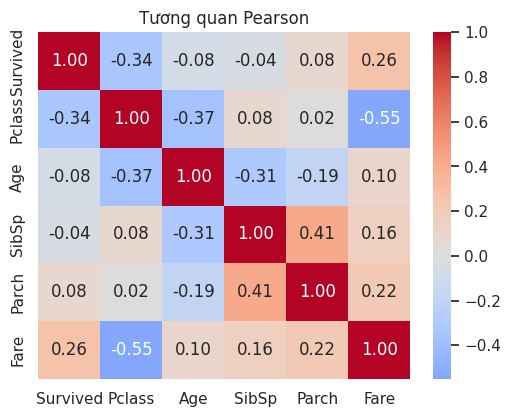

Độ lệch (skew):
Survived    0.48
Pclass     -0.63
Age         0.39
SibSp       3.70
Parch       2.75
Fare        4.79
dtype: float64


In [4]:
num = train[["Survived","Pclass","Age","SibSp","Parch","Fare"]]
plt.figure(figsize=(6,4.5)); sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.title("Tương quan Pearson"); plt.show()
print("Độ lệch (skew):"); print(num.skew().round(2))

**Nhận xét**
- **Giới tính là tín hiệu mạnh nhất**: nữ sống ~74%, nam ~19%. Hạng vé thứ hai: hạng 1 sống ~63%, hạng 3 chỉ ~24%.
- `Fare` lệch phải mạnh → nên biến đổi log hoặc chuẩn hóa. `Fare` và `Pclass` tương quan âm (−0.55) → thông tin chồng lấn.
- Cảng `C` có tỉ lệ sống cao hơn, nhưng điều này có thể chỉ phản ánh tỉ lệ hành khách hạng 1 nhiều hơn ở cảng đó (biến gây nhiễu) – cần kiểm chứng thay vì suy ra quan hệ nhân quả.

## 3. Chuẩn bị dữ liệu
**Chia validation trước khi làm bất cứ điều gì học từ dữ liệu** (tránh *data leakage*): 80% để huấn luyện/CV, 20% giữ lại cuối cùng.



In [5]:
class FeatureBuilder(BaseEstimator, TransformerMixin):
    """Tạo đặc trưng mới. Median tuổi theo Title chỉ học từ dữ liệu fit() -> không rò rỉ."""
    def fit(self, X, y=None):
        t = self._title(X)
        self.age_by_title_ = X.assign(Title=t).groupby("Title")["Age"].median().to_dict()
        self.age_global_ = X["Age"].median()
        self.fare_median_ = X["Fare"].median()
        return self
    @staticmethod
    def _title(X):
        t = X["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
        t = t.replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
        return t.where(t.isin(["Mr","Mrs","Miss","Master"]), "Rare")
    def transform(self, X):
        D = pd.DataFrame(index=X.index)
        D["Title"] = self._title(X)
        D["Pclass"] = X["Pclass"].astype(str)          # xem hạng vé là biến phân loại
        D["Sex"] = X["Sex"]
        D["Embarked"] = X["Embarked"]
        age = X["Age"].copy()
        D["AgeMissing"] = age.isna().astype(int)
        D["Age"] = age.fillna(D["Title"].map(self.age_by_title_)).fillna(self.age_global_)
        D["FamilySize"] = X["SibSp"] + X["Parch"] + 1
        D["IsAlone"] = (D["FamilySize"] == 1).astype(int)
        D["HasCabin"] = X["Cabin"].notna().astype(int)
        D["LogFare"] = np.log1p(X["Fare"].fillna(self.fare_median_))
        return D

cat_cols = ["Title","Pclass","Sex","Embarked"]
num_cols = ["Age","FamilySize","LogFare"]
bin_cols = ["AgeMissing","IsAlone","HasCabin"]

def make_prep(scale=True):
    num_steps = [("imp", SimpleImputer(strategy="median"))] + ([("sc", StandardScaler())] if scale else [])
    return Pipeline([("fe", FeatureBuilder()),
                     ("ct", ColumnTransformer([
                         ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                           ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
                         ("num", Pipeline(num_steps), num_cols),
                         ("bin", "passthrough", bin_cols)]))])

def make_model(clf, scale=True): return Pipeline([("prep", make_prep(scale)), ("clf", clf)])

X = train.drop(columns="Survived"); y = train["Survived"]
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train:", X_tr.shape, " validation:", X_val.shape)
print("Tỉ lệ sống  train=%.3f  val=%.3f" % (y_tr.mean(), y_val.mean()))
display(FeatureBuilder().fit(X_tr).transform(X_tr.head()))

train: (712, 11)  validation: (179, 11)
Tỉ lệ sống  train=0.383  val=0.385


,Title,Pclass,Sex,Embarked,AgeMissing,Age,FamilySize,IsAlone,HasCabin,LogFare
517,Mr,3,male,Q,1,30.0,1,1,0,3.224858
89,Mr,3,male,S,0,24.0,1,1,0,2.202765
45,Mr,3,male,S,1,30.0,1,1,0,2.202765
708,Miss,1,female,S,0,22.0,1,1,0,5.027492
137,Mr,1,male,S,0,37.0,2,0,1,3.990834


## 4. Đánh giá thuật toán
Test harness: **Repeated Stratified 10-fold CV (3 lần lặp)** trên tập train. Chạy *spot-check* 6 thuật toán như trong sách (LR, LDA, KNN, NB, CART, SVM) + **hai phiên bản: không chuẩn hóa và có chuẩn hóa** để thấy tác động của scaling.

In [6]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=SEED)
models = {"LR":LogisticRegression(max_iter=2000), "LDA":LinearDiscriminantAnalysis(), "KNN":KNeighborsClassifier(),
          "NB":GaussianNB(), "CART":DecisionTreeClassifier(random_state=SEED), "SVM":SVC()}
res = {}
for scale in (False, True):
    for n, m in models.items():
        s = cross_val_score(make_model(m, scale), X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1)
        res[(n, "Standardized" if scale else "Raw")] = s
summary = pd.DataFrame({k:(v.mean(), v.std()) for k,v in res.items()}, index=["mean","std"]).T.round(4)
display(summary.unstack(level=1))

mean                  std             
         Raw Standardized     Raw Standardized
CART  0.7837       0.7855  0.0456       0.0445
KNN   0.7959       0.8066  0.0420       0.0371
LDA   0.8291       0.8291  0.0315       0.0315
LR    0.8249       0.8240  0.0284       0.0295
NB    0.7982       0.7982  0.0311       0.0311
SVM   0.7088       0.8295  0.0337       0.0407

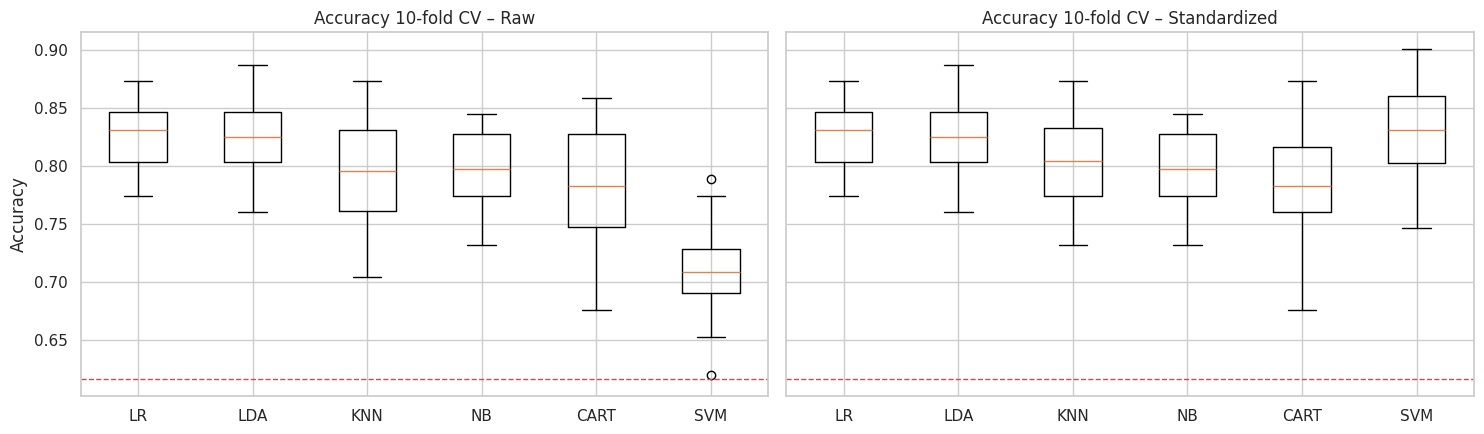

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for a, tag in zip(ax, ["Raw","Standardized"]):
    a.boxplot([res[(n,tag)] for n in models], labels=list(models)); a.set_title(f"Accuracy 10-fold CV – {tag}"); a.axhline(0.616, ls="--", c="r", lw=1)
ax[0].set_ylabel("Accuracy"); plt.tight_layout(); plt.show()

## 5. Cải thiện kết quả

### 5.1 Tinh chỉnh tham số (Grid Search) cho 3 ứng viên tốt nhất

In [8]:
cv5 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
grids = {
 "SVM": (SVC(probability=True, random_state=SEED), {"clf__C":[0.5,1,2,5,10], "clf__gamma":["scale",0.02,0.05,0.1], "clf__kernel":["rbf"]}),
 "LR":  (LogisticRegression(max_iter=3000),       {"clf__C":[0.03,0.1,0.3,1,3,10]}),
 "KNN": (KNeighborsClassifier(),                  {"clf__n_neighbors":[5,7,9,11,15,21], "clf__weights":["uniform","distance"]}),
}
tuned = {}
for n,(m,g) in grids.items():
    gs = GridSearchCV(make_model(m), g, cv=cv5, scoring="accuracy", n_jobs=-1).fit(X_tr, y_tr)
    tuned[n] = gs.best_estimator_
    print(f"{n:4s} best CV acc = {gs.best_score_:.4f}   params = {gs.best_params_}")

SVM  best CV acc = 0.8385   params = {'clf__C': 2, 'clf__gamma': 0.05, 'clf__kernel': 'rbf'}


LR   best CV acc = 0.8272   params = {'clf__C': 3}


KNN  best CV acc = 0.8272   params = {'clf__n_neighbors': 15, 'clf__weights': 'uniform'}


### 5.2 Phương pháp Ensemble (Bagging, Boosting, Voting)

,mean,std
SVM (tuned),0.8380,0.0322
Voting(SVM+LR+GBM+RF),0.8342,0.0314
RF,0.8328,0.0419
KNN (tuned),0.8309,0.0418
GBM,0.8286,0.0381
LR (tuned),0.8263,0.0320
ET,0.8263,0.0427
AdaBoost,0.8188,0.0352


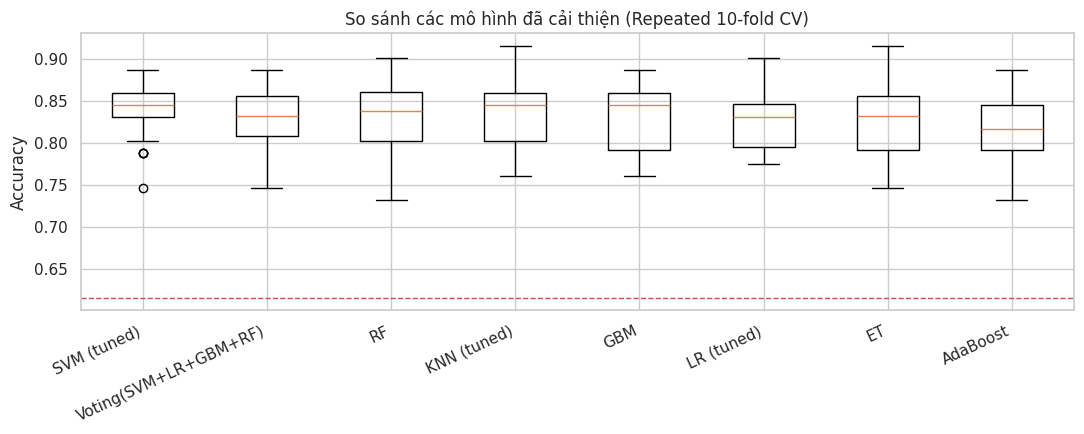

In [9]:
ens = {"RF":RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=SEED),
       "ET":ExtraTreesClassifier(n_estimators=300, min_samples_leaf=2, random_state=SEED),
       "GBM":GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=SEED),
       "AdaBoost":AdaBoostClassifier(n_estimators=150, learning_rate=0.5, random_state=SEED)}
ens_res = {n: cross_val_score(make_model(m, scale=False), X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1) for n,m in ens.items()}

vote = VotingClassifier([("svm", tuned["SVM"].named_steps["clf"]), ("lr", tuned["LR"].named_steps["clf"]),
                         ("gbm", ens["GBM"]), ("rf", ens["RF"])], voting="soft")
ens_res["Voting(SVM+LR+GBM+RF)"] = cross_val_score(make_model(vote), X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1)
for n in tuned: ens_res[f"{n} (tuned)"] = cross_val_score(tuned[n], X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1)

tab = pd.DataFrame({k:(v.mean(), v.std()) for k,v in ens_res.items()}, index=["mean","std"]).T.sort_values("mean", ascending=False).round(4)
display(tab)
plt.figure(figsize=(11,4.5)); order=list(tab.index); plt.boxplot([ens_res[k] for k in order], labels=order, vert=True); plt.xticks(rotation=25, ha="right")
plt.axhline(0.616, ls="--", c="r", lw=1); plt.title("So sánh các mô hình đã cải thiện (Repeated 10-fold CV)"); plt.ylabel("Accuracy"); plt.tight_layout(); plt.show()

## 6. Trình bày kết quả
### 6.1 Chốt mô hình và kiểm tra trên tập validation 
Mô hình chọn dựa trên CV ở phần 5 

Mô hình chọn: SVM (tuned)
Validation  accuracy=0.8212  F1=0.7538  ROC-AUC=0.8318
Baseline 'nữ sống, nam chết' (kiểu gender_submission): accuracy=0.7654
Baseline 'luôn đoán chết': accuracy=0.6145

              precision    recall  f1-score   support

        Chết       0.83      0.89      0.86       110
        Sống       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



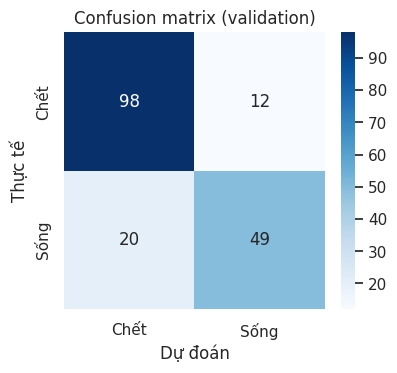

In [10]:
best_name = tab.index[0]
cands = {"Voting(SVM+LR+GBM+RF)": make_model(vote), "SVM (tuned)": tuned["SVM"], "LR (tuned)": tuned["LR"], "KNN (tuned)": tuned["KNN"],
         "RF": make_model(ens["RF"],False), "ET": make_model(ens["ET"],False), "GBM": make_model(ens["GBM"],False), "AdaBoost": make_model(ens["AdaBoost"],False)}
final = cands[best_name].fit(X_tr, y_tr)
pred = final.predict(X_val); proba = final.predict_proba(X_val)[:,1]
print(f"Mô hình chọn: {best_name}")
print(f"Validation  accuracy={accuracy_score(y_val,pred):.4f}  F1={f1_score(y_val,pred):.4f}  ROC-AUC={roc_auc_score(y_val,proba):.4f}")
base_gender = (X_val["Sex"]=="female").astype(int)
print(f"Baseline 'nữ sống, nam chết' (kiểu gender_submission): accuracy={accuracy_score(y_val,base_gender):.4f}")
print(f"Baseline 'luôn đoán chết': accuracy={1-y_val.mean():.4f}\n")
print(classification_report(y_val, pred, target_names=["Chết","Sống"]))
fig, ax = plt.subplots(1,1, figsize=(4.2,3.6))
sns.heatmap(confusion_matrix(y_val,pred), annot=True, fmt="d", cmap="Blues", xticklabels=["Chết","Sống"], yticklabels=["Chết","Sống"], ax=ax)
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế"); ax.set_title("Confusion matrix (validation)"); plt.show()

### 6.2 Đặc trưng nào quan trọng? (Random Forest – permutation importance trên validation)

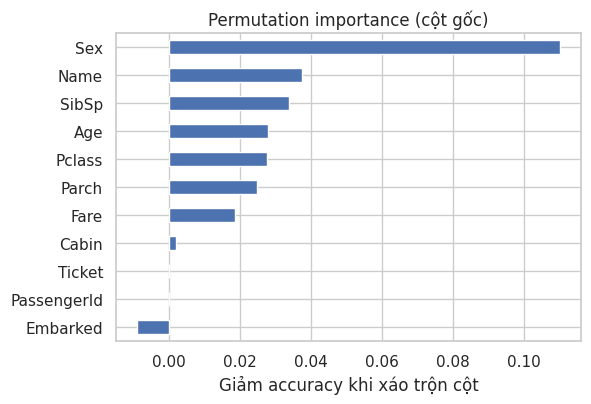

In [11]:
from sklearn.inspection import permutation_importance
rf = make_model(ens["RF"], False).fit(X_tr, y_tr)
pi = permutation_importance(rf, X_val, y_val, n_repeats=30, random_state=SEED, scoring="accuracy")
# permutation được tính trên cột GỐC của X_val (trước pipeline) nên kết quả gọn theo từng cột ban đầu
imp = pd.Series(pi.importances_mean, index=X_val.columns).sort_values()
imp.plot.barh(figsize=(6,4)); plt.title("Permutation importance (cột gốc)"); plt.xlabel("Giảm accuracy khi xáo trộn cột"); plt.show()

### 6.3 Huấn luyện lại trên toàn bộ `train.csv`, dự đoán `test.csv`, lưu mô hình

In [12]:
final_all = cands[best_name].fit(X, y)                       # dùng hết 891 dòng
test_pred = final_all.predict(test)
sub = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": test_pred})
sub.to_csv("titanic_submission.csv", index=False)
joblib.dump(final_all, "titanic_final_model.joblib")
g = pd.read_csv(f"{DATA_DIR}/gender_submission.csv")
print("Đã lưu titanic_submission.csv (%d dòng), tỉ lệ dự đoán sống = %.3f" % (len(sub), sub.Survived.mean()))
print("Độ trùng với gender_submission.csv: %.1f%%" % (100*(sub.Survived.values==g.Survived.values).mean()))
# kiểm tra nạp lại mô hình
print("Nạp lại mô hình OK:", (joblib.load("titanic_final_model.joblib").predict(test.head(5))==test_pred[:5]).all())
sub.head()

Đã lưu titanic_submission.csv (418 dòng), tỉ lệ dự đoán sống = 0.383
Độ trùng với gender_submission.csv: 94.3%
Nạp lại mô hình OK: True


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### Kết luận
- Đã đi qua đủ 6 bước của template. Mô hình cuối vượt xa baseline "luôn đoán chết", và cao hơn baseline "giới tính" khoảng 5 điểm % trên validation – **phần lớn sức mạnh dự đoán của Titanic đến từ giới tính, hạng vé và Title**; các kỹ thuật phức tạp hơn chỉ cải thiện vài điểm %.
- Chênh lệch giữa các mô hình top đầu **nhỏ hơn độ lệch chuẩn của CV** → không nên kết luận "mô hình A tốt hơn B" chỉ dựa vào chênh lệch ~0.5%.
- Validation chỉ có 179 dòng nên độ tin cậy của con số cuối có sai số khoảng ±3%.
